# 4.1.2 吸引域扰动与有限时间扫描

## 学习目标与先修知识

能区分初始扰动和持续偏置，用显式中点法（explicit midpoint method）扫描初值（initial condition），保留有限时间未决标签，并用解析解（analytical solution）检查数值误差（numerical error）。

先修：上一节的相线（phase line）、解析解与吸引域（basin of attraction）；第 2 篇的欧拉法（forward Euler method）和误差比较。 [复习上一节](01-从三个平衡进入多稳态.ipynb)。

## 具体问题

一个低活动状态（state）受到短刺激后，可能恢复，也可能转到高活动状态。刺激改变起点与外界持续偏置改变规则，为什么是两种不同的实验？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
kick=np.array([.8,1.,1.2])
after=-1+kick
display(Markdown(show_table(['扰动 Δ','扰动后 x','去向'],[(d,x,'−1' if x<0 else '1' if x>0 else '精确保持 0') for d,x in zip(kick,after)])))

| 扰动 Δ | 扰动后 x | 去向 |
| --- | --- | --- |
| 0.8 | -0.2 | −1 |
| 1 | 0 | 精确保持 0 |
| 1.2 | 0.2 | 1 |

## 模型假设

活动偏差 x 和时间 τ 都无量纲（dimensionless）。持续偏置模型（model）为 x′=x−x³+b，b 在一次轨迹（trajectory）中保持常数。初始刺激只改 x0；瞬时刺激可在某时刻将状态替换为 x+Δ，之后恢复同一方程。

初值扫描使用 b=0，观察窗口 τ=4 与 12，分类阈值为 0.9：末态低于 −0.9 记“负侧”，高于 0.9 记“正侧”，其他记“未越阈值”。这个有限时间标签不直接命名为吸引域。

## 数学解释与推导

欧拉法只用段首斜率（slope）。**显式中点法**先用半步预测中间状态，再以中点斜率推进整个步长：
$$k_1=f(x_n),\quad m=x_n+\frac h2 k_1,\quad x_{n+1}=x_n+h f(m).$$
为什么值得做两次斜率计算？对自治标量方程，沿解有 x″=f′(x)f(x)，所以真实一步展开为 x+h f(x)+h²f′(x)f(x)/2+O(h³)。把中点预测代入 f(m)≈f(x)+hf′(x)f(x)/2，就补回二阶项。在解足够光滑且有限窗口误差稳定的条件下，全局误差通常是 O(h²)。这里给出算法与关键展开；完整误差界放在进一步阅读。

它仍是数值近似，不保证任意大步长都保持原系统方向或吸引域。实际用 h、h/2、h/4 对照 b=0 的独立解析式；减小 h 时误差约降到四分之一，才支持进入二阶收敛区。

边界附近 x′≈x，故小的非零 x0 先按 x0 exp(τ) 离开。达到固定可见大小约需时间 log(可见大小/|x0|)：初值越接近零，等待越久。这解释了有限窗口中的“未决”，而非创造新平衡（equilibrium）。

瞬时扰动从 −1 跳到 −1+Δ。Δ<1 且仍为负时回到负侧；Δ=1 精确停在不稳定零点；Δ>1 时进入正侧。持续 b>0 却在每个时刻都给方程增加一项，旧的 −1、0、1 都不再是平衡，不能用初始扰动代替。

有限初值网格只能定位边界区间。已知本例的解析流向后，才可把边界精确定位为零；推广到未知系统时要保留网格分辨率、观察时间和未决结果。

## 核心实现

将推导中的每一步明确写成计算。

In [3]:
def switch_exact(initial,times):
    result=[]
    for t in times:
        if initial==0:
            result.append(0.0)
        else:
            square=initial*initial
            result.append(initial/math.sqrt(square+(1-square)*math.exp(-2*t)))
    return result

def switch_step(state,bias,h):
    first=state-state**3+bias
    middle=state+h*first/2
    return state+h*(middle-middle**3+bias)

def switch_path(initial,bias,h,steps):
    values=[initial]
    for _ in range(steps):
        values.append(switch_step(values[-1],bias,h))
    return values

def basin_scan(initials,h,steps,threshold):
    final=[switch_path(x,0,h,steps)[-1] for x in initials]
    labels=[-1 if x < -threshold else 1 if x > threshold else 0 for x in final]
    return final,labels

## 对照实验

| 初值 | 末态 τ=4 | 阈值标签 |
| --- | --- | --- |
| -0.2 | -0.995998 | -1 |
| -0.02 | -0.737533 | 0 |
| -0.002 | -0.108544 | 0 |
| 0 | 0 | 0 |
| 0.002 | 0.108544 | 0 |
| 0.02 | 0.737533 | 0 |
| 0.2 | 0.995998 | 1 |

| 初值 | 末态 τ=12 | 阈值标签 |
| --- | --- | --- |
| -0.2 | -1 | -1 |
| -0.02 | -1 | -1 |
| -0.002 | -0.999995 | -1 |
| 0 | 0 | 0 |
| 0.002 | 0.999995 | 1 |
| 0.02 | 1 | 1 |
| 0.2 | 1 | 1 |

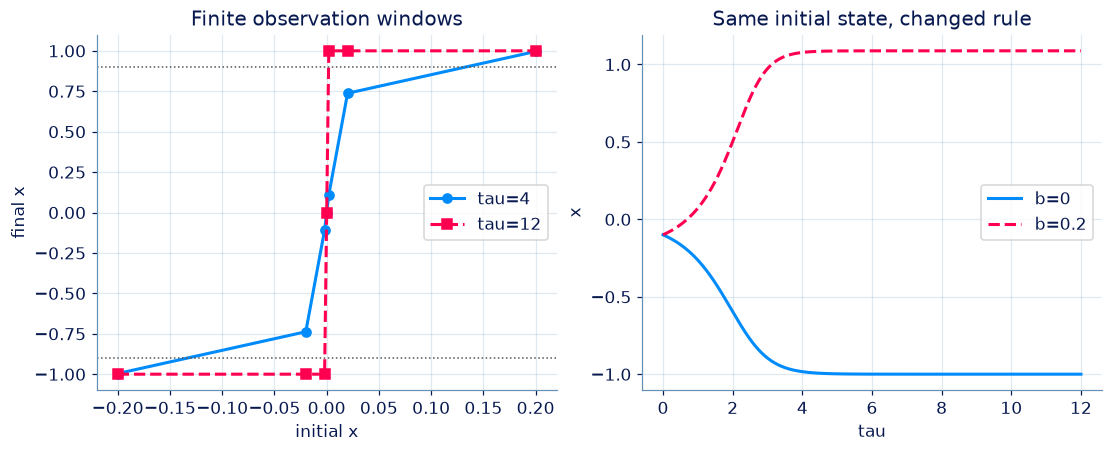

In [4]:
initials=np.array([-.2,-.02,-.002,0,.002,.02,.2])
fig,axes=plt.subplots(1,2,figsize=(10,4))
for end,color,style in [(4,BLUE,'o-'),(12,PINK,'s--')]:
    final,labels=basin_scan(initials,.01,int(end/.01),.9)
    axes[0].plot(initials,final,style,color=color,label=f'tau={end}')
    display(Markdown(show_table(['初值',f'末态 τ={end}','阈值标签'],zip(initials,final,labels))))
axes[0].axhline(.9,color=GRAY,ls=':',lw=1);axes[0].axhline(-.9,color=GRAY,ls=':',lw=1)
times=np.arange(1201)*.01
for bias,color,style in [(0,BLUE,'-'),(.2,PINK,'--')]:
    axes[1].plot(times,switch_path(-.1,bias,.01,1200),color=color,ls=style,label=f'b={bias}')
axes[0].set(xlabel='initial x',ylabel='final x',title='Finite observation windows')
axes[1].set(xlabel='tau',ylabel='x',title='Same initial state, changed rule')
for ax in axes:ax.legend()
plt.show()

## 结果解释

左图两种观察时间使用同一组初值，小初值在短窗口内仍可能未越阈值。右图固定 x0=−0.1 后改变 b，展示持续规则变化；两种对照不能混作同一原因。

试着把最小非零初值再缩小十倍，同时将观察时间增加 log(10)。先预测何时能看到分离，再修改参数（parameter）检验；最后用本节选择题核对有限扫描能支持的结论。

### 独立核对

收敛检查使用独立闭式解；同时检查精确零平衡和等于阈值时的规则，避免程序把数值噪声当成状态切换。

In [5]:
errors=[]
for h in [.04,.02,.01]:
    numerical=switch_path(.15,0,h,round(4/h))[-1]
    errors.append(abs(numerical-switch_exact(.15,[4])[0]))
display(Markdown(show_table(['h','终点绝对误差'],zip([.04,.02,.01],errors))))
assert errors[0]>3*errors[1]>9*errors[2]
assert switch_path(0,0,.05,100)==[0]*101
assert basin_scan([-.9,.9],.01,0,.9)[1]==[0,0]
print('解析对照收敛、零平衡与严格阈值边界通过。')

| h | 终点绝对误差 |
| --- | --- |
| 0.04 | 2.09848e-05 |
| 0.02 | 5.12694e-06 |
| 0.01 | 1.26743e-06 |

解析对照收敛、零平衡与严格阈值边界通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/04-01-多稳态与吸引域/explore/)：先预测条件变化的后果，再用交互对照本节推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：扫描初值但保留未决状态

对 x′=x−x³ 进行显式中点法（explicit midpoint method）积分，用有限观察时刻的状态（state）做阈值分类。分类 0 表示尚未越过阈值，不等同于平衡（equilibrium）或吸引域（basin of attraction）已确定。

**函数与代码模板**

```python
def solve(
    initials: list[float],
    h: float,
    steps: int,
    threshold: float,
) -> tuple[list[float], list[int]]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initials` | `list[float]` | 待比较的初值（initial condition）。 | 1 |
| `h` | `float` | 每步无量纲（dimensionless）时间长度。 | 1 |
| `steps` | `int` | 每个初值积分的步数。 | 1 |
| `threshold` | `float` | 分类阈值。 | 1 |

**返回值**

按以下顺序返回元组：(final_states, labels)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `final_states` | `list[float]` | 对应每个初值的末态。 | 1 |
| `labels` | `list[int]` | x<−threshold 为 −1，x>threshold 为 1，其余为 0。 | 1 |

**计算规则**

每步先计算 k1=x−x³，m=x+h*k1/2，再同步更新 x←x+h*(m−m³)；恰做 steps 步。用严格不等式分类。

**约束与边界**

- 所有输入（input）数值有限；不修改输入列表。
- initials 长度 1—20，各项在 [−1.5,1.5]；0<h≤0.05；0≤steps≤3000；0<threshold<1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initials | 待比较的初值（initial condition）。 | [-0.5, 0, 0.5] | 1 |
| h | 每步无量纲（dimensionless）时间长度。 | 0.05 | 1 |
| steps | 每个初值积分的步数。 | 1 | 1 |
| threshold | 分类阈值。 | 0.6 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initials = [-0.5, 0, 0.5]
h = 0.05
steps = 1
threshold = 0.6

result = solve(initials, h, steps, threshold)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| final_states | 对应每个初值的末态。 | [-0.5188605545043945, 0.0, 0.5188605545043945] | 1 |
| labels | x<−threshold 为 −1，x>threshold 为 1，其余为 0。 | [0, 0, 0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([-0.5188605545043945,
                    0.0,
                    0.5188605545043945],
                   [0, 0, 0])
```

**样例解释**

只推进一步，两个非零末态绝对值都小于 0.6，因此三项标签均为 0；这没有否定非零初值最终趋向 ±1。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：扫描初值但保留未决状态](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-basin-window)

### 第 2 题 · Python 计算题：用半步预测计算整步更新

对带偏置的开关 x′=x−x³+bias，完成一个显式中点法（explicit midpoint method）更新。

**函数与代码模板**

```python
def solve(
    state: float,
    bias: float,
    h: float,
) -> float:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `float` | 当前 x。 | 1 |
| `bias` | `float` | 本步保持不变的偏置。 | 1 |
| `h` | `float` | 整步时间长度。 | 1 |

**返回值**

直接返回 next_state（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `next_state` | `float` | 一个整步后的近似 x。 | 1 |

**计算规则**

first=state−state³+bias；middle=state+h*first/2；next_state=state+h*(middle−middle³+bias)。第二次斜率（slope）必须在 middle 处计算。

**约束与边界**

- 所有输入（input）数值有限；不修改输入列表。
- −1.5≤state≤1.5；−0.6≤bias≤0.6；0≤h≤0.05。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 当前 x。 | 0 | 1 |
| bias | 本步保持不变的偏置。 | 0.4 | 1 |
| h | 整步时间长度。 | 0.05 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = 0
bias = 0.4
h = 0.05

result = solve(state, bias, h)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| next_state | 一个整步后的近似 x。 | 0.02049995 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 0.020499950000000003
```

**样例解释**

first=0.4，middle=0.01；下一状态（state）为 0.05×(0.01−0.01³+0.4)=0.02049995。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：用半步预测计算整步更新](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-midpoint-step)

### 第 3 题 · 多项选择题：瞬时扰动是否越过边界

无偏置开关已经在 x=−1。瞬时扰动把状态（state）改成 −1+Δ，随后恢复原方程。哪些成立？

- **A.** Δ=1.2 后趋向 1。
- **B.** 只要 Δ>0 就会切换到 1。
- **C.** Δ=0.8 后回到 −1。
- **D.** Δ=1 后精确留在 0，但对再扰动敏感。

[作答：瞬时扰动是否越过边界](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-kick-basin)

### 第 4 题 · 单项选择题：初值网格能给出精确边界吗

只计算初值（initial condition） −0.01、0.01，观察到末态分别接近 −1、1。哪项表述最稳妥？

- **A.** 再增加一条任意轨迹（trajectory）就能证明所有初值的结论。
- **B.** 已数值证明边界恰为 0。
- **C.** 这两条轨迹只约束边界所在区间；结合方程流向和唯一性才可说明本例边界为 0。
- **D.** 边界肯定是 0.01。

[作答：初值网格能给出精确边界吗](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-finite-grid)

### 第 5 题 · 多项选择题：偏置改变的是规则还是起点

把 x′=x−x³ 改成 x′=x−x³+0.1，并保持同一初值（initial condition）。哪些成立？

- **A.** 这是参数（parameter）变化，改变整个流向函数。
- **B.** 平衡（equilibrium）仍必定为 −1、0、1。
- **C.** x=0 时新的初始变化率为 0.1。
- **D.** 与只在时刻 0 增加状态（state） 0.1 完全等价。

[作答：偏置改变的是规则还是起点](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-bias-shift)